# Minimal didactic model 
This notebook reimplements only the core model mechanics needed to reproduce the Figure 5d-style output: mean learned value trajectories for CS+ and CS-, with and without MDN-like feedback.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Set model and environment parameters

In [ ]:
## Simulation Parameters

S = 11  # Number of spatial states in the 1D arena.
T = 400  # Number of timesteps.
SCENTER = math.floor(S / 2)  # Center state.


## Model parameters
N = 2000  # Number of KCs.
N_ACTIVE_KCS = 100  # Number of active KCs per odour (active rate = 1 / N_ACTIVE_KCS).
INITIAL_WEIGHT = 1.0  # Initial KC-to-MBON weight.
ETA = 0.1  # Learning rate in the manuscript.
GAMMA = 0.8  # Temporal discount factor in the manuscript.
B = 0.8  # DAN external reinforcement balance term in the manuscript.
WEIGHT_SUM_TARGET = 2.0  # Target of subtractive normalization.
NORMALIZATION_RATE = 0.025  # Per-pathway normalization rate each timestep.

MDN_SIGNAL = 0.1  # MDN_t when MDN condition is met.
VALUE_THRESHOLD = 0.01  # Value threshold for action probabilities and MDN value gating.

ACTIONS = np.asarray([1, -1, 0])  # [approach, avoid, stay].
ACTION_PROBS_POSITIVE_VALUE = np.asarray([0.8, 0.1, 0.1])
ACTION_PROBS_NEGATIVE_VALUE = np.asarray([0.1, 0.8, 0.1])
ACTION_PROBS_NEUTRAL_VALUE = np.asarray([0.4, 0.4, 0.2])

## Set up functions to run the model in the environment

### Model notation used below

This notebook mirrors the variable names and flow in the modelling section of the methods:

- `k_t`: KC activity; odours activate non-overlapping KC subsets, active rate `1` inactive rate `0`.
- `m_ap`, `m_av`: approach and avoidance MBON activities.
- `V = m_ap - m_av`: current odour value estimate used for action selection.
- `pi_ap`, `pi_av`: temporal prediction components using `gamma` and consecutive KC patterns.
- `d_p`, `d_r`: punishment- and reward-responsive DAN activities, including optional MDN terms.
- `w_ap`, `w_av`: KC-to-MBON weights updated with learning rate `eta` and subtractive normalization toward `WEIGHT_SUM_TARGET`.
- `b`: DAN balance term in the external reward/punishment drive.

In [6]:
def build_odor_map(rng):
    if 2 * N_ACTIVE_KCS > N:
        raise ValueError('Need at least 2 * N_ACTIVE_KCS total KCs for non-overlapping odour subsets.')

    all_kcs = np.arange(N)
    odor_1_kcs = rng.choice(all_kcs, size=N_ACTIVE_KCS, replace=False)
    remaining_kcs = np.setdiff1d(all_kcs, odor_1_kcs)
    odor_2_kcs = rng.choice(remaining_kcs, size=N_ACTIVE_KCS, replace=False)

    odor_1_activity = np.zeros(N)
    odor_2_activity = np.zeros(N)
    odor_1_activity[odor_1_kcs] = 1.0 
    odor_2_activity[odor_2_kcs] = 1.0 

    kc_activity_by_state = np.zeros((S, N))
    kc_activity_by_state[: math.floor(S / 2), :] = odor_1_activity
    kc_activity_by_state[-math.floor(S / 2) :, :] = odor_2_activity
    return kc_activity_by_state, odor_1_activity, odor_2_activity


def is_at_env_end(curr_s):
    return (curr_s == 0) or (curr_s == S - 1)


def get_action_probabilities(value_estimate):
    if value_estimate > VALUE_THRESHOLD:
        return ACTION_PROBS_POSITIVE_VALUE
    if value_estimate < -VALUE_THRESHOLD:
        return ACTION_PROBS_NEGATIVE_VALUE
    return ACTION_PROBS_NEUTRAL_VALUE


def choose_action(value_estimate):
    return np.random.choice(ACTIONS, p=get_action_probabilities(value_estimate))


def run_minimal_simulation(seed, mdn_feedback=False):
    if not isinstance(mdn_feedback, bool):
        raise TypeError('mdn_feedback must be a boolean (True or False)')

    np.random.seed(seed)
    subset_rng = np.random.default_rng(seed)  # Isolated stream so KC sampling does not shift action randomness.


    reinforcement_by_state = np.zeros(S)
    reinforcement_by_state[0] = 1.0
    reinforcement_by_state[-1] = -1.0

    endzones = np.zeros(S)
    endzones[0] = 1
    endzones[-1] = -1
    endzone_t = np.zeros(T)

    kc_activity_by_state, odor_1_activity, odor_2_activity = build_odor_map(subset_rng)

    w_ap = np.zeros((T, N))
    w_av = np.zeros((T, N))
    odor_values = np.zeros((T, 2))
    m_ap = np.zeros(T)
    m_av = np.zeros(T)
    V = np.zeros(T)
    s = np.zeros(T, dtype=int)
    s[0] = SCENTER

    w_ap[0] = INITIAL_WEIGHT
    w_av[0] = INITIAL_WEIGHT
    odor_values[0] = [
        (w_ap[0] - w_av[0]) @ odor_1_activity,
        (w_ap[0] - w_av[0]) @ odor_2_activity,
    ]

    for t in range(T - 1):
        reinforcement_t = reinforcement_by_state[s[t]]
        endzone_t[t] = endzones[s[t]]

        if is_at_env_end(s[t]):
            s[t + 1] = SCENTER
            current_action = 0
        else:
            current_action = choose_action(V[t])
            if s[t] < SCENTER:
                current_action = -current_action
            s[t + 1] = s[t] + current_action


        k_t = kc_activity_by_state[s[t]]
        k_t_1 = kc_activity_by_state[s[t + 1]]

        m_ap[t + 1] = w_ap[t] @ k_t_1
        m_av[t + 1] = w_av[t] @ k_t_1
        V[t + 1] = m_ap[t + 1] - m_av[t + 1]

        pi_ap = GAMMA * w_ap[t]@k_t_1 - w_ap[t]@k_t
        pi_av = GAMMA * w_av[t]@k_t_1 - w_av[t]@k_t

        r_t = max(reinforcement_t, 0.0) # external reward
        p_t = max(-reinforcement_t, 0.0) # external punishment

        mdn_t = 0.0
        if mdn_feedback and current_action == -1 and V[t] < -VALUE_THRESHOLD:
            mdn_t = MDN_SIGNAL

        d_p = B * p_t - (1 - B) * r_t + 0.5 * (pi_av - pi_ap) + 2.0 * mdn_t
        d_r = B * r_t - (1 - B) * p_t + 0.5 * (pi_ap - pi_av) + mdn_t

        w_av[t + 1] = w_av[t] - ETA/N_ACTIVE_KCS * d_r * k_t
        w_ap[t + 1] = w_ap[t] - ETA/N_ACTIVE_KCS * d_p * k_t

        normalization_shift = WEIGHT_SUM_TARGET - (w_ap[t + 1] + w_av[t + 1])
        w_ap[t + 1] += NORMALIZATION_RATE * normalization_shift
        w_av[t + 1] += NORMALIZATION_RATE * normalization_shift

        odor_values[t + 1] = [
            (w_ap[t + 1] - w_av[t + 1]) @ odor_1_activity,
            (w_ap[t + 1] - w_av[t + 1]) @ odor_2_activity,
        ]

    endzone_t[T - 1] = endzones[s[T - 1]]
    return odor_values, endzone_t

## Run the model and plot results

In [ ]:
SEED = 1

W_no_mdn_feedback, endzone_no_mdn_feedback = run_minimal_simulation(seed=SEED, mdn_feedback=False)
W_with_mdn_feedback, endzone_with_mdn_feedback = run_minimal_simulation(seed=SEED, mdn_feedback=True)

W_no_mdn_feedback shape: (400, 2)
W_with_mdn_feedback shape: (400, 2)


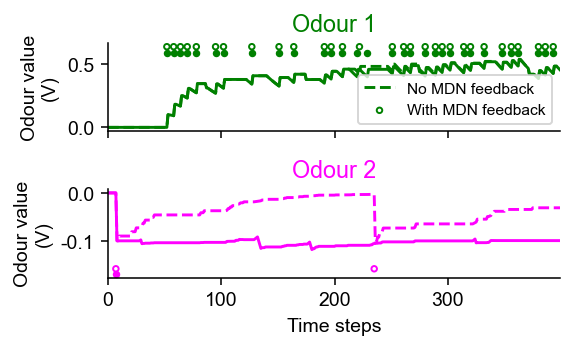

In [5]:
def plot_values(ax, W, endzone, T, valmax, valmin, odor, dashed_line=False, alpha=1.0):
    col = 'green' if odor == 0 else 'magenta'
    ls = '--' if dashed_line else '-'
    ax.plot(W[:, odor], color=col, ls=ls, alpha=alpha)

    rtime = endzone > 0
    ptime = endzone < 0

    if odor == 0:
        ax.scatter(
            np.arange(T)[rtime],
            valmax * np.ones(np.sum(rtime)) + 0.05 * int(dashed_line),
            color=col,
            s=8,
            alpha=alpha,
            facecolors='none' if dashed_line else col,
        )
    else:
        ax.scatter(
            np.arange(T)[ptime],
            valmin * np.ones(np.sum(ptime)) + 0.01 * int(dashed_line),
            color=col,
            s=8,
            alpha=alpha,
            facecolors='none' if dashed_line else col,
        )


valmax = np.max(np.concatenate([W_no_mdn_feedback.reshape(-1), W_with_mdn_feedback.reshape(-1)])) + 0.05
valmin = np.min(np.concatenate([W_no_mdn_feedback.reshape(-1), W_with_mdn_feedback.reshape(-1)])) - 0.05

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(4.2, 2.6))

# Dashed: no MDN feedback
plot_values(axs[0], W_no_mdn_feedback, endzone_no_mdn_feedback.astype(int), T, valmax, valmin, odor=0, dashed_line=True, alpha=1.0)
plot_values(axs[1], W_no_mdn_feedback, endzone_no_mdn_feedback.astype(int), T, valmax, valmin, odor=1, dashed_line=True, alpha=1.0)

# Solid: with MDN feedback
plot_values(axs[0], W_with_mdn_feedback, endzone_with_mdn_feedback.astype(int), T, valmax, valmin, odor=0, dashed_line=False, alpha=1.0)
plot_values(axs[1], W_with_mdn_feedback, endzone_with_mdn_feedback.astype(int), T, valmax, valmin, odor=1, dashed_line=False, alpha=1.0)

axs[0].set_ylabel('Odour value\n(V)')
axs[1].set_ylabel('Odour value\n(V)')
axs[0].set_title('Odour 1', color='green')
axs[1].set_title('Odour 2', color='magenta')
axs[1].set_xlabel('Time steps')

for ax in axs:
    ax.set_xlim(0, T - 1)
    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FormatStrFormatter('%.1f'))

axs[0].legend(['No MDN feedback', 'With MDN feedback'], loc='best', fontsize=8)
fig.tight_layout()
plt.show()